# Vela Analysis (exploratory)

First-principles build-up for the BTC 15-min binary fade (current dataset, Jun 17–27 2026). Each section asks **one question, draws one chart, ends with a one-line read**.

It's a **template**: the *knobs* cell sets every bin edge and the window horizon, and everything downstream re-renders when you change them. Bins are deliberately non-uniform — fine where the density and the action concentrate, coarse in the tails.

Build order: spot tape → one window → the payoff → the move → probability & calibration → market & edge → execution → attribution.

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# two spot feeds — Binance (BTC/USDT) and Coinbase (BTC/USD), 1s OHLCV
spot = pd.read_parquet("../analysis/data/binance_1s_btc_full.parquet")   # Binance
cb   = pd.read_parquet("../analysis/data/coinbase_1s_btc.parquet")        # Coinbase
for d in (spot, cb):
    d["time"] = pd.to_datetime(d["epoch_sec"], unit="s", utc=True)
bn_px = spot.set_index("epoch_sec").close   # fast avg-at-close lookup
cb_px = cb.set_index("epoch_sec").close

# Kalshi settlements (basis reference) + gated windows + fade events
con = sqlite3.connect("file:../livepaper/data_btc/paper.db?mode=ro", uri=True)
dbz = pd.read_sql("select ticker,close_ts,binance_avg60,true_settle from debias "
                  "where ticker like 'KXBTC15M%' order by close_ts", con)
win = pd.read_sql("select ticker,asset,close_ts,strike,true_settle,result,"
                  "bet_side,gate_active,won,net_pnl from windows", con)
con.close()
ev = pd.read_parquet("../analysis/data/fill_calibration_btc.parquet")

print(f"binance {len(spot):,} | coinbase {len(cb):,} | settlements {len(dbz)} | windows {len(win)} | fades {len(ev)}")

binance 950,401 | coinbase 856,816 | settlements 1167 | windows 97 | fades 1034


In [2]:
# ============ KNOBS — edit, then re-run the sections below ============
HORIZON_SEC = 900       # window length under study (15-min markets)
BIAS_LOOKBACK_N = 96    # prior resolved windows the debias medians over (shorter = tracks drift faster, noisier)
COMBINE_W = 0.5         # weight on Coinbase in the combined feed (0 = Binance only, 1 = Coinbase only)

# Each entry is either a LIST of fixed (non-uniform) edges -> pd.cut,
# or an INT N -> N equal-count adaptive bins (pd.qcut). Flip any one to switch.
BINS = {
    # secs-to-close: last minute only — the fade fires ~45s, fills land 11-45s
    "ttc":    [0, 15, 30, 45, 60],
    # model P(side): tight around the live gates (0.84 BTC / 0.98 ETH) and near 1
    "p_side": [0.50, 0.60, 0.70, 0.80, 0.84, 0.90, 0.95, 0.98, 0.99, 1.001],
    # |spot - strike| ($): tight near 0 (coin-flip), wide when decisive
    "margin": [0, 5, 10, 20, 40, 80, 160, 320, np.inf],
    # hour of day (UTC)
    "hour":   list(range(0, 25, 2)),
}

def buckets(s, spec):
    if isinstance(spec, int):                    # adaptive: N equal-count (qcut) bins
        return pd.qcut(s, spec, duplicates="drop")
    return pd.cut(s, spec, include_lowest=True)  # fixed: explicit edges

## 1 · BTC/time

Two feeds, raw — Binance (USDT) runs persistently above Coinbase (USD).

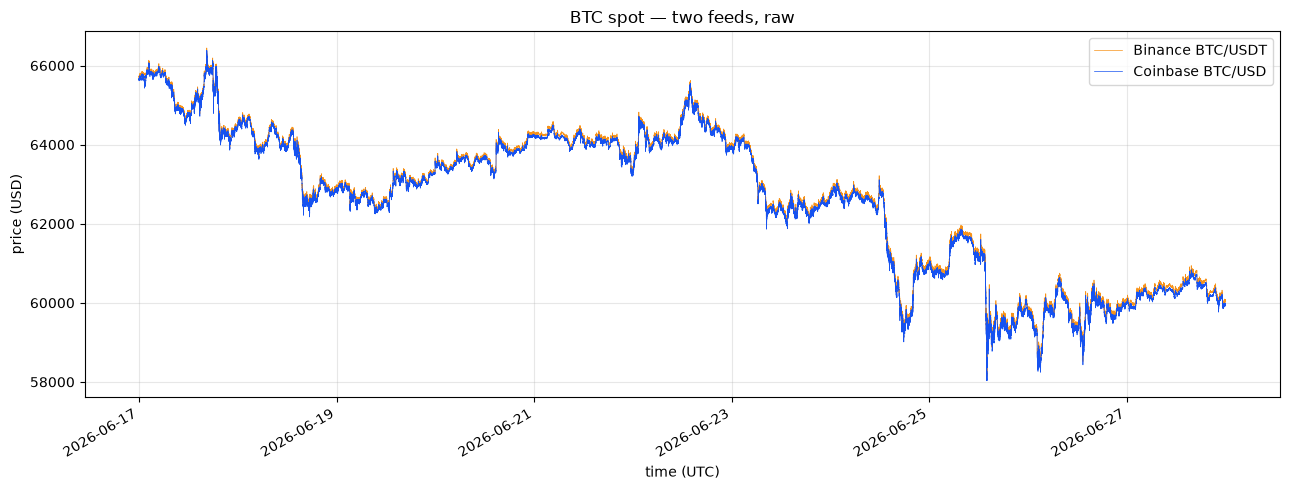

In [3]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spot.time, spot.close, lw=0.5, color="#f7931a", label="Binance BTC/USDT")
ax.plot(cb.time,   cb.close,   lw=0.5, color="#1652f0", label="Coinbase BTC/USD")
ax.set_title("BTC spot — two feeds, raw")
ax.set_xlabel("time (UTC)")
ax.set_ylabel("price (USD)")
ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 2 · BTC/time - 15min window

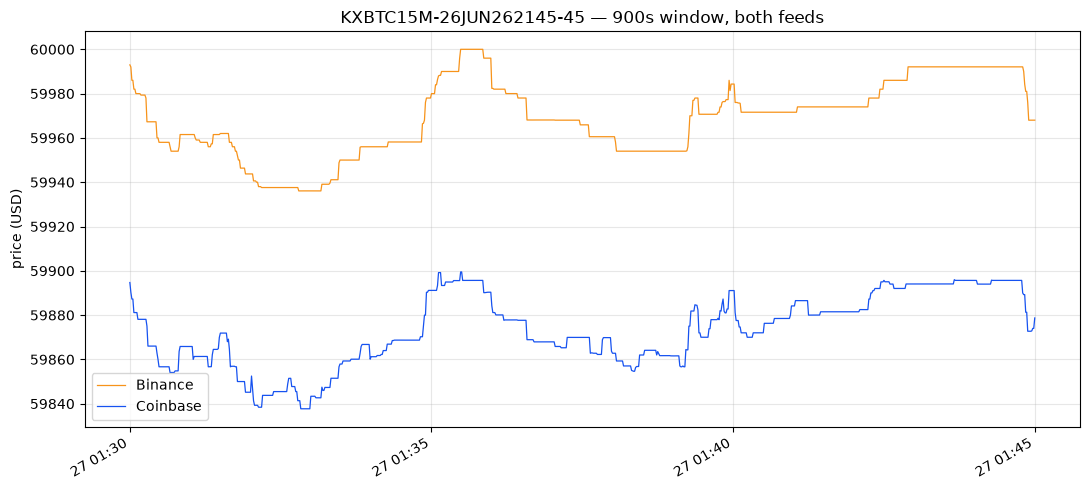

In [4]:
WINDOW_TICKER = "KXBTC15M-26JUN262145-45"   # edit to inspect any window
cts = int(win.loc[win.ticker == WINDOW_TICKER, "close_ts"].iloc[0])
seg = lambda d: d[d.epoch_sec.between(cts - HORIZON_SEC, cts)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(seg(spot).time, seg(spot).close, lw=0.9, color="#f7931a", label="Binance")
ax.plot(seg(cb).time,   seg(cb).close,   lw=0.9, color="#1652f0", label="Coinbase")
ax.set_title(f"{WINDOW_TICKER} — {HORIZON_SEC}s window, both feeds")
ax.set_ylabel("price (USD)"); ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 3 · Debias — signal vs settlement

You *signal* off a feed but *settle* off Kalshi. Below: each feed's error vs the Kalshi settle (`feed_avg60 − true_settle`). Binance runs ~$70 high and drifts; Coinbase nearly tracks it (Kalshi's USD index ≈ a Coinbase-style reference).

**How we debias:** for each window, estimate the bias as the **median error over the previous `BIAS_LOOKBACK_N` resolved windows** (past only), then subtract it from the live combined feed. A rolling median lags a drifting bias — shorter `BIAS_LOOKBACK_N` tracks the drift faster but is noisier.

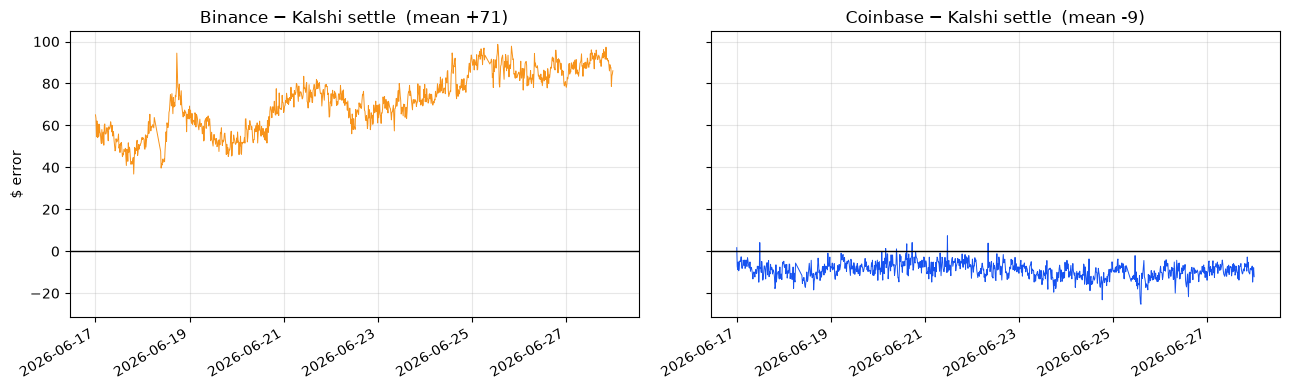

In [5]:
# per-window: each feed's last-60s average before close, vs the Kalshi settle
dbz["bn60"] = dbz.close_ts.map(lambda c: bn_px.loc[c - 59:c].mean())
dbz["cb60"] = dbz.close_ts.map(lambda c: cb_px.loc[c - 59:c].mean())
dbz = dbz.dropna(subset=["bn60", "cb60"]).reset_index(drop=True)
dbz["err_bn"] = dbz.bn60 - dbz.true_settle
dbz["err_cb"] = dbz.cb60 - dbz.true_settle
t = pd.to_datetime(dbz.close_ts, unit="s", utc=True)

fig, ax = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
ax[0].plot(t, dbz.err_bn, lw=0.7, color="#f7931a"); ax[0].axhline(0, color="k", lw=1)
ax[0].set_title(f"Binance − Kalshi settle  (mean {dbz.err_bn.mean():+.0f})"); ax[0].set_ylabel("$ error")
ax[1].plot(t, dbz.err_cb, lw=0.7, color="#1652f0"); ax[1].axhline(0, color="k", lw=1)
ax[1].set_title(f"Coinbase − Kalshi settle  (mean {dbz.err_cb.mean():+.0f})")
for a in ax: a.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

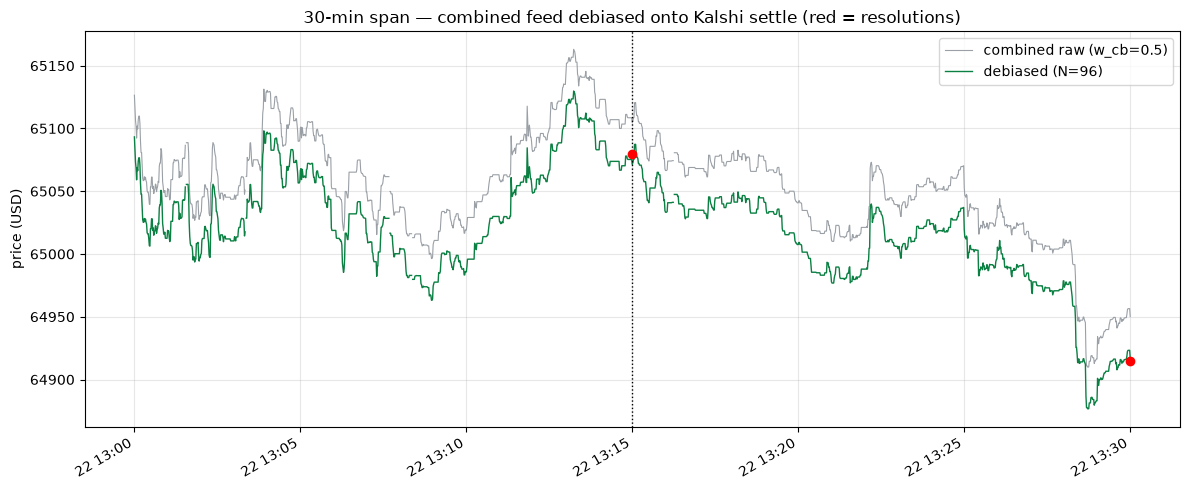

A bias +33.2 → residual -3.5   |   B bias +33.2 → residual -3.8


In [6]:
# combined feed + rolling-median debias from prior resolutions
dbz["combined60"] = COMBINE_W * dbz.cb60 + (1 - COMBINE_W) * dbz.bn60
dbz["err"]  = dbz.combined60 - dbz.true_settle
dbz["bias"] = dbz.err.shift(1).rolling(BIAS_LOOKBACK_N, min_periods=10).median()

# 30-min span = two consecutive 15-min windows; debias each from its own prior resolutions
pairs = dbz[(dbz.close_ts.shift(-1) - dbz.close_ts == 900) & dbz.bias.notna()]
A = pairs.iloc[len(pairs) // 2]
B = dbz[dbz.close_ts == A.close_ts + 900].iloc[0]
lo, hi = int(A.close_ts) - 900, int(B.close_ts)

px = pd.DataFrame(index=pd.RangeIndex(lo, hi + 1, name="epoch_sec"))
px["combined"] = COMBINE_W * cb_px.reindex(px.index) + (1 - COMBINE_W) * bn_px.reindex(px.index)
px["bias"] = np.where(px.index <= A.close_ts, A.bias, B.bias)   # each window uses its own bias
px["debiased"] = px.combined - px.bias
tt = pd.to_datetime(px.index, unit="s", utc=True)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(tt, px.combined, lw=0.8, color="#9aa0a6", label=f"combined raw (w_cb={COMBINE_W})")
ax.plot(tt, px.debiased, lw=1.0, color="#0b8043", label=f"debiased (N={BIAS_LOOKBACK_N})")
for r in (A, B):
    ax.scatter(pd.to_datetime(r.close_ts, unit="s", utc=True), r.true_settle, color="red", zorder=5)
ax.axvline(pd.to_datetime(A.close_ts, unit="s", utc=True), color="k", ls=":", lw=1)
ax.set_title("30-min span — combined feed debiased onto Kalshi settle (red = resolutions)")
ax.set_ylabel("price (USD)"); ax.legend(); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()
print(f"A bias {A.bias:+.1f} → residual {A.err - A.bias:+.1f}   |   "
      f"B bias {B.bias:+.1f} → residual {B.err - B.bias:+.1f}")

## 4 · Margin

Settlement is binary, margin = `settle − strike`.

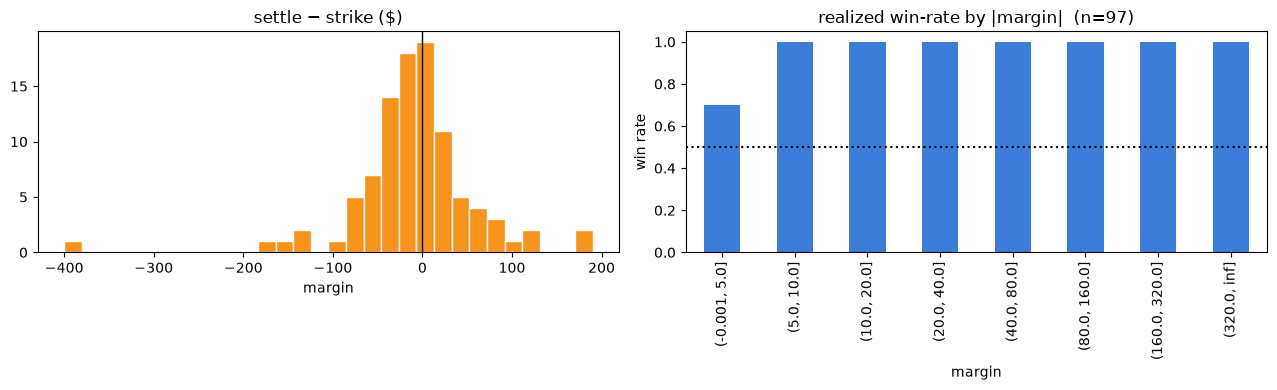

In [7]:
win = win.assign(margin=win.true_settle - win.strike)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(win.margin, bins=30, color="#f7931a", edgecolor="white")
ax[0].axvline(0, color="k", lw=1)
ax[0].set_title("settle − strike ($)"); ax[0].set_xlabel("margin")

wr = win.groupby(buckets(win.margin.abs(), BINS["margin"]), observed=True).won.mean()
wr.plot.bar(ax=ax[1], color="#3b7dd8")
ax[1].axhline(0.5, color="k", ls=":"); ax[1].set_ylim(0, 1.05)
ax[1].set_title(f"realized win-rate by |margin|  (n={len(win)})"); ax[1].set_ylabel("win rate")
plt.tight_layout(); plt.show()

## 5 · The move — what determines settlement

The binary is written on the return from now to close. Here's the 1s return distribution and the realized 1σ dollar move over one window — the scale the strike has to be beaten by.

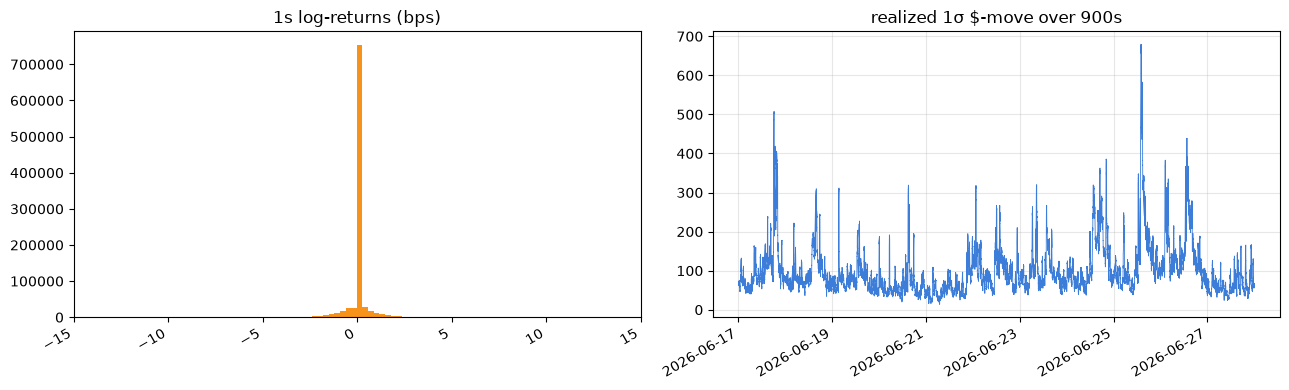

In [8]:
spot["logret"] = np.log(spot.close).diff()
sigma_win = spot.logret.rolling(HORIZON_SEC).std() * np.sqrt(HORIZON_SEC) * spot.close

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(spot.logret.dropna() * 1e4, bins=200, color="#f7931a")
ax[0].set_xlim(-15, 15); ax[0].set_title("1s log-returns (bps)")
ax[1].plot(spot.time, sigma_win, lw=0.6, color="#3b7dd8")
ax[1].set_title(f"realized 1σ $-move over {HORIZON_SEC}s"); ax[1].grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 6 · Probability & calibration

Does model `P(side)` match realized outcomes? Only *filled* attempts have a settled result, and the gate truncates the sample to `P ≈ 1` — so the testable range is narrow. That truncation is itself the read.

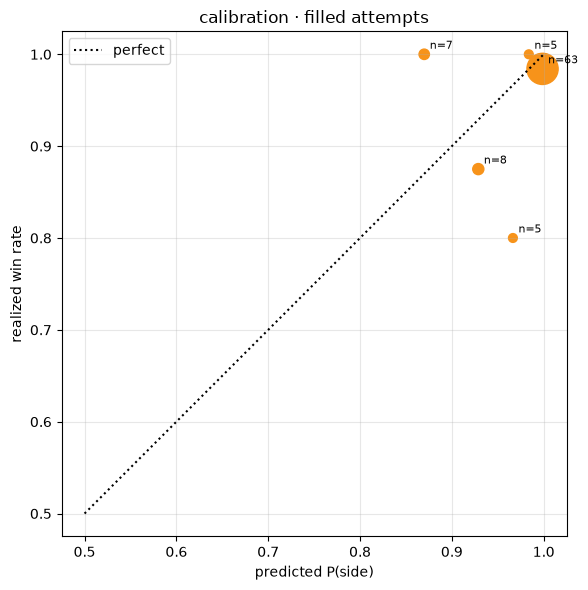

In [9]:
cal = ev.dropna(subset=["won"])
rel = (cal.groupby(buckets(cal.p_side, BINS["p_side"]), observed=True)
          .agg(pred=("p_side", "mean"), real=("won", "mean"), n=("won", "size")).dropna())

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0.5, 1], [0.5, 1], "k:", label="perfect")
ax.scatter(rel.pred, rel.real, s=rel.n * 8, color="#f7931a")
for _, r in rel.iterrows():
    ax.annotate(f"n={int(r.n)}", (r.pred, r.real), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("predicted P(side)"); ax.set_ylabel("realized win rate")
ax.set_title("calibration · filled attempts"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7 · The market & the edge

Model vs Kalshi. `edge = P(side) − mid`: positive means the model sees more probability than the price charged.

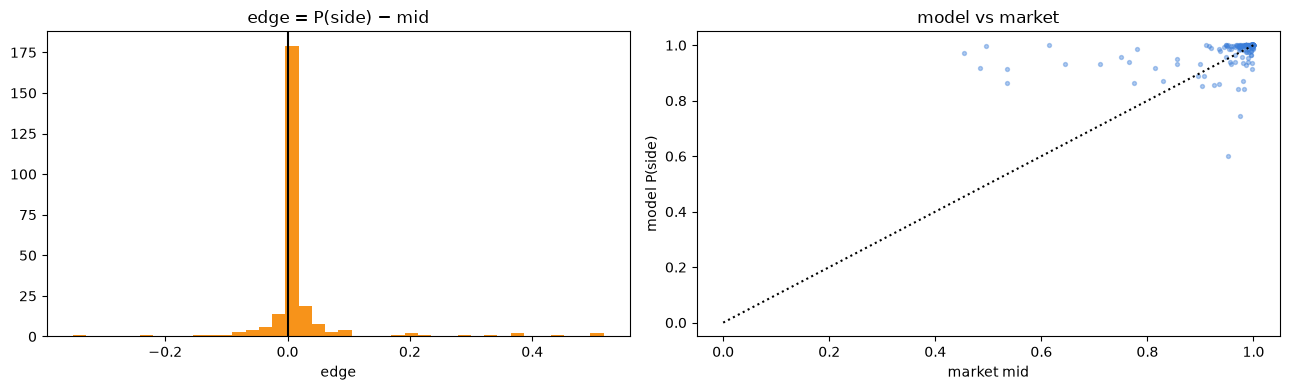

In [10]:
mk = ev.dropna(subset=["mid"]).assign(edge=lambda d: d.p_side - d.mid)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(mk.edge, bins=40, color="#f7931a"); ax[0].axvline(0, color="k")
ax[0].set_title("edge = P(side) − mid"); ax[0].set_xlabel("edge")
ax[1].scatter(mk.mid, mk.p_side, s=8, alpha=0.4, color="#3b7dd8"); ax[1].plot([0, 1], [0, 1], "k:")
ax[1].set_xlabel("market mid"); ax[1].set_ylabel("model P(side)"); ax[1].set_title("model vs market")
plt.tight_layout(); plt.show()

## 8 · Execution reality — fills & adverse selection

The fade rests a maker bid; most never fill. The real question isn't whether gated windows win — it's whether the *filled* ones do, and whether fills cluster on the wrong side.

fill rate          : 8.5%  (88/1034)
win rate | filled  : 96.6%
P(side) all/filled : 0.996 / 0.979
net PnL | filled   : mean +0.180   total +15.87


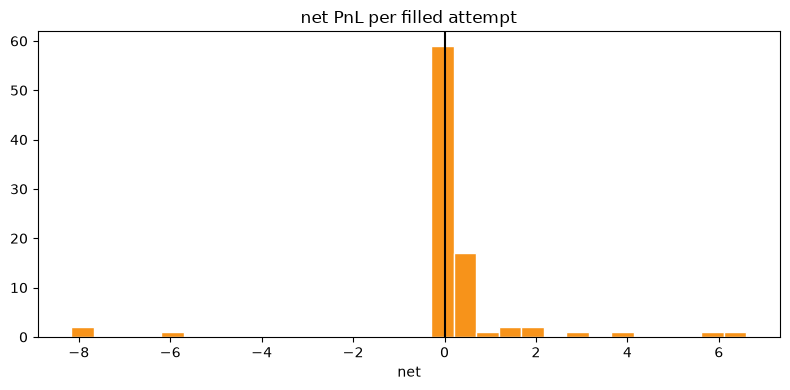

In [11]:
filled = ev[ev.filled == 1]
print(f"fill rate          : {ev.filled.mean():.1%}  ({len(filled)}/{len(ev)})")
print(f"win rate | filled  : {filled.won.mean():.1%}")
print(f"P(side) all/filled : {ev.p_side.mean():.3f} / {filled.p_side.mean():.3f}")
print(f"net PnL | filled   : mean {filled.net_pnl.mean():+.3f}   total {filled.net_pnl.sum():+.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(filled.net_pnl, bins=30, color="#f7931a", edgecolor="white"); ax.axvline(0, color="k")
ax.set_title("net PnL per filled attempt"); ax.set_xlabel("net")
plt.tight_layout(); plt.show()

## 9 · Attribution — slice PnL by any bucket

The template payoff: set `BY`, reshape the edges in the knobs cell, re-run. Re-slicing is multiple testing — what pops is a hypothesis for the confirmatory notebook, not a finding.

                n    win    pnl    avg
p_side                                
(0.84, 0.9]     7  1.000  11.08  1.583
(0.9, 0.95]     8  0.875   9.31  1.164
(0.95, 0.98]    5  0.800  -5.12 -1.024
(0.98, 0.99]    5  1.000   1.49  0.298
(0.99, 1.001]  63  0.984  -0.89 -0.014


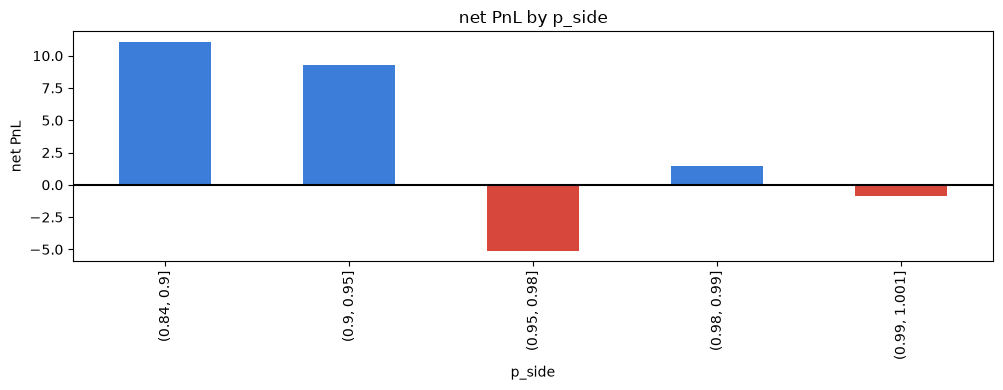

In [12]:
BY = "p_side"            # p_side · ttc · hour
COL = {"p_side": "p_side", "ttc": "time_to_close", "hour": "hour"}[BY]

f = ev[ev.filled == 1].copy()
f["hour"] = pd.to_datetime(f.ts_ms, unit="ms", utc=True).dt.hour
tab = (f.groupby(buckets(f[COL], BINS[BY]), observed=True)
         .agg(n=("net_pnl", "size"), win=("won", "mean"),
              pnl=("net_pnl", "sum"), avg=("net_pnl", "mean")).dropna())
print(tab.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
tab.pnl.plot.bar(ax=ax, color=["#3b7dd8" if v >= 0 else "#d8473b" for v in tab.pnl])
ax.axhline(0, color="k"); ax.set_title(f"net PnL by {BY}"); ax.set_ylabel("net PnL")
plt.tight_layout(); plt.show()